In [2]:
import os
import glob
import matplotlib.pyplot as plt
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

## Set up PySpark Session

In [3]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 14:19:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Directories

In [4]:
bronze_lms_directory = "datalake/bronze/lms/"
bronze_fin_directory = "datalake/bronze/financial/"
bronze_attr_directory = "datalake/bronze/attributes/"
bronze_click_directory = "datalake/bronze/clickstream/"

# Financial EDA

In [5]:
# Load all bronze financial CSVs at once and process
all_fin_files = glob.glob(os.path.join(bronze_fin_directory, '*.csv'))
df = spark.read.csv(all_fin_files, header=True, inferSchema=True)
print(f"loaded {len(all_fin_files)} files, total row count: {df.count()}")

column_type_map = {
    "Customer_ID": StringType(),
    "Annual_Income": FloatType(),
    "Monthly_Inhand_Salary": FloatType(),
    "Num_Bank_Accounts": IntegerType(),
    "Num_Credit_Card": IntegerType(),
    "Interest_Rate": IntegerType(),
    "Num_of_Loan": IntegerType(),
    "Type_of_Loan": StringType(),
    "Delay_from_due_date": IntegerType(),
    "Num_of_Delayed_Payment": IntegerType(),
    "Changed_Credit_Limit": FloatType(),
    "Num_Credit_Inquiries": IntegerType(),
    "Credit_Mix": StringType(),
    "Outstanding_Debt": FloatType(),
    "Credit_Utilization_Ratio": FloatType(),
    "Credit_History_Age": StringType(),
    "Payment_of_Min_Amount": StringType(),
    "Total_EMI_per_month": FloatType(),
    "Amount_invested_monthly": FloatType(),
    "Payment_Behaviour": StringType(),
    "Monthly_Balance": FloatType(),
    "snapshot_date": DateType()
}

numeric_cols = [(c, t) for c, t in column_type_map.items() if isinstance(t, (FloatType, IntegerType))]
for column, col_type in numeric_cols:
    df = df.withColumn(column, F.regexp_replace(col(column).cast(StringType()), "_", ""))

for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))

loaded 24 files, total row count: 11974


In [6]:
df.toPandas()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x10ac,16718.644531,1270.220459,7,3,15,4,"Credit-Builder Loan, Credit-Builder Loan, Home...",26,11,...,_,853.409973,31.397339,16 Years and 3 Months,No,50.961937,36.413094,!@9#%8,319.647003,2024-08-01
1,CUS_0x10c5,158623.156250,13180.596680,2,7,10,1,Payday Loan,10,5,...,Good,1134.829956,41.796799,30 Years and 2 Months,No,91.033905,282.718689,High_spent_Medium_value_payments,1194.307129,2024-08-01
2,CUS_0x1145,17975.320312,1444.943359,6,5,32,9,"Student Loan, Payday Loan, Not Specified, Mort...",61,25,...,Bad,1263.099976,25.681799,12 Years and 5 Months,Yes,76.450325,176.776215,Low_spent_Small_value_payments,181.267792,2024-08-01
3,CUS_0x11ac,69136.539062,5902.378418,3,4,14,0,None,14,18,...,Standard,478.850006,32.103165,17 Years and 5 Months,Yes,0.000000,435.937012,Low_spent_Small_value_payments,444.300842,2024-08-01
4,CUS_0x122c,36346.128906,3188.844238,8,6,11,3,"Credit-Builder Loan, Home Equity Loan, and Aut...",21,15,...,Good,1252.459961,28.066704,22 Years and 2 Months,NM,89.061554,110.509705,High_spent_Medium_value_payments,369.313171,2024-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11969,CUS_0xd50,43771.851562,3600.654053,4,3,9,1,Student Loan,-2,1,...,Good,1337.250000,37.227306,25 Years and 9 Months,No,29.648878,45.186573,High_spent_Large_value_payments,525.229980,2024-10-01
11970,CUS_0xde4,75402.523438,6221.543457,2,4,3,3,"Not Specified, Auto Loan, and Mortgage Loan",0,5,...,Good,725.969971,27.774990,28 Years and 1 Months,No,177.208908,69.716797,!@9#%8,615.228638,2024-10-01
11971,CUS_0xe16,37976.679688,2997.723389,9,9,18,7,"Auto Loan, Personal Loan, Student Loan, Person...",56,24,...,Bad,4505.100098,26.221207,8 Years and 10 Months,Yes,148.765701,40.587112,High_spent_Large_value_payments,350.419525,2024-10-01
11972,CUS_0xe7a,7711.970215,395.664154,10,5,29,7,"Debt Consolidation Loan, Home Equity Loan, Per...",57,21,...,Bad,4709.029785,26.277349,0 Years and 11 Months,Yes,29.560299,44.311394,Low_spent_Small_value_payments,255.694717,2024-10-01


## '_' and Empty String Check

In [7]:
# Expose bare "_" and empty strings as null so we can count true missing values
fin_df = df.select(*[
    F.when((F.col(c).cast("string") == "_") | (F.col(c).cast("string") == ""), None)
     .otherwise(F.col(c)).alias(c)
    for c in df.columns
])

## Boxplot of numerical columns (Histogram)

Numerical columns: ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


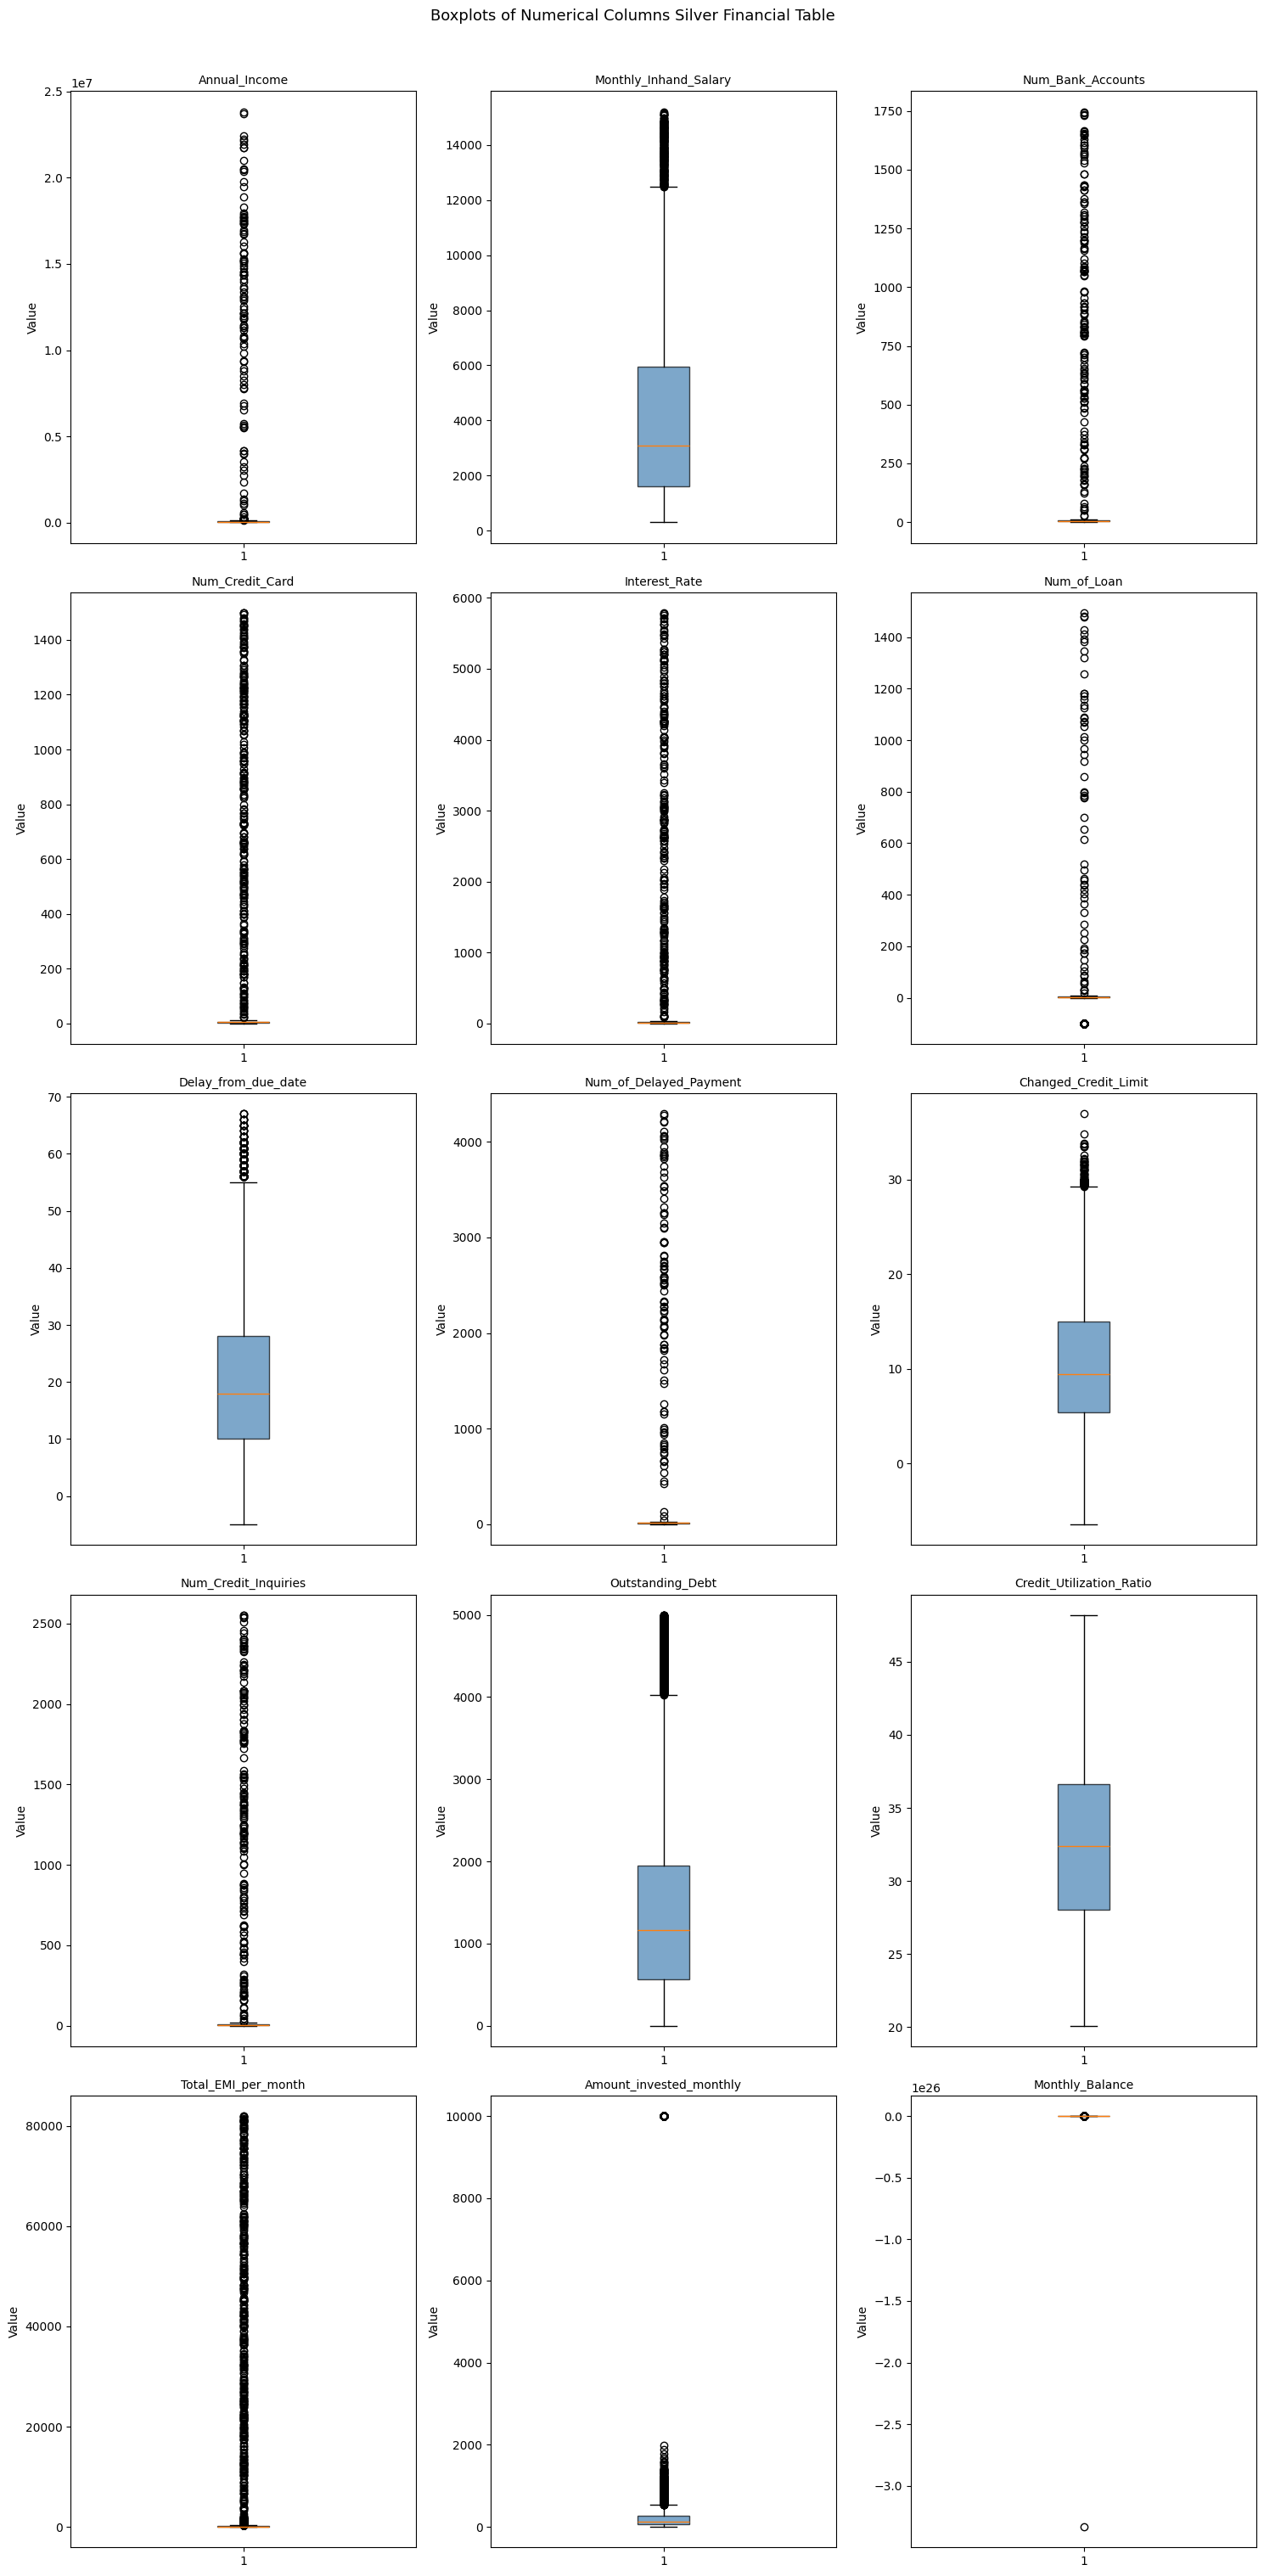

In [8]:
# Identify numerical columns from schema
from pyspark.sql.types import NumericType
num_cols = [f.name for f in fin_df.schema.fields if isinstance(f.dataType, NumericType)]
print("Numerical columns:", num_cols)

# Convert to pandas only for visualization
fin_pdf = fin_df.toPandas()

fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.flatten()

for i, col_name in enumerate(num_cols):
    axes[i].boxplot(fin_pdf[col_name].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col_name, fontsize=10)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Columns Silver Financial Table', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Negative Values Check

In [9]:
# Remove rows where any numerical column contains a negative value
print(f"Rows before negative removal: {fin_df.count()}")

filtered_df = fin_df
for col_name in num_cols:
    before = filtered_df.count()
    filtered_df = filtered_df.filter(col(col_name) >= 0)
    removed = before - filtered_df.count()
    if removed > 0:
        print(f"{col_name}: removed {removed} rows with negative values")

print(f"Rows after negative removal: {filtered_df.count()}")
filtered_df.show(5)

Rows before negative removal: 11974
Num_Bank_Accounts: removed 4 rows with negative values
Num_of_Loan: removed 486 rows with negative values
Delay_from_due_date: removed 78 rows with negative values
Num_of_Delayed_Payment: removed 81 rows with negative values
Changed_Credit_Limit: removed 419 rows with negative values
Monthly_Balance: removed 1 rows with negative values
Rows after negative removal: 10905
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Cre

## Outlier Analysis

In [10]:
# Specify which columns to apply outlier removal on
cols_to_clip = [
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

print(f"Rows before outlier removal: {filtered_df.count()}")

for col_name in cols_to_clip:
    Q1, Q3 = filtered_df.approxQuantile(col_name, [0.25, 0.75], 0.0)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = filtered_df.count()
    filtered_df = filtered_df.filter((col(col_name) >= lower) & (col(col_name) <= upper))
    removed = before - filtered_df.count()
    print(f"  {col_name}: whiskers [{lower:.2f}, {upper:.2f}] removes {removed} rows")

print(f"Rows after outlier removal: {filtered_df.count()}")

Rows before outlier removal: 10905
  Annual_Income: whiskers [-60412.42, 152109.95] removes 292 rows
  Monthly_Inhand_Salary: whiskers [-4650.10, 12021.43] removes 87 rows
  Num_Bank_Accounts: whiskers [-2.00, 14.00] removes 146 rows
  Num_Credit_Card: whiskers [-0.50, 11.50] removes 256 rows
  Interest_Rate: whiskers [-11.50, 40.50] removes 219 rows
  Num_of_Loan: whiskers [-2.50, 9.50] removes 56 rows
  Num_of_Delayed_Payment: whiskers [-4.50, 31.50] removes 82 rows


  Num_Credit_Inquiries: whiskers [-5.00, 19.00] removes 147 rows
  Outstanding_Debt: whiskers [-1596.13, 4208.78] removes 439 rows
  Total_EMI_per_month: whiskers [-168.84, 362.60] removes 693 rows


  Amount_invested_monthly: whiskers [-187.11, 501.78] removes 901 rows


  Monthly_Balance: whiskers [-2.21, 735.56] removes 570 rows
Rows after outlier removal: 7017


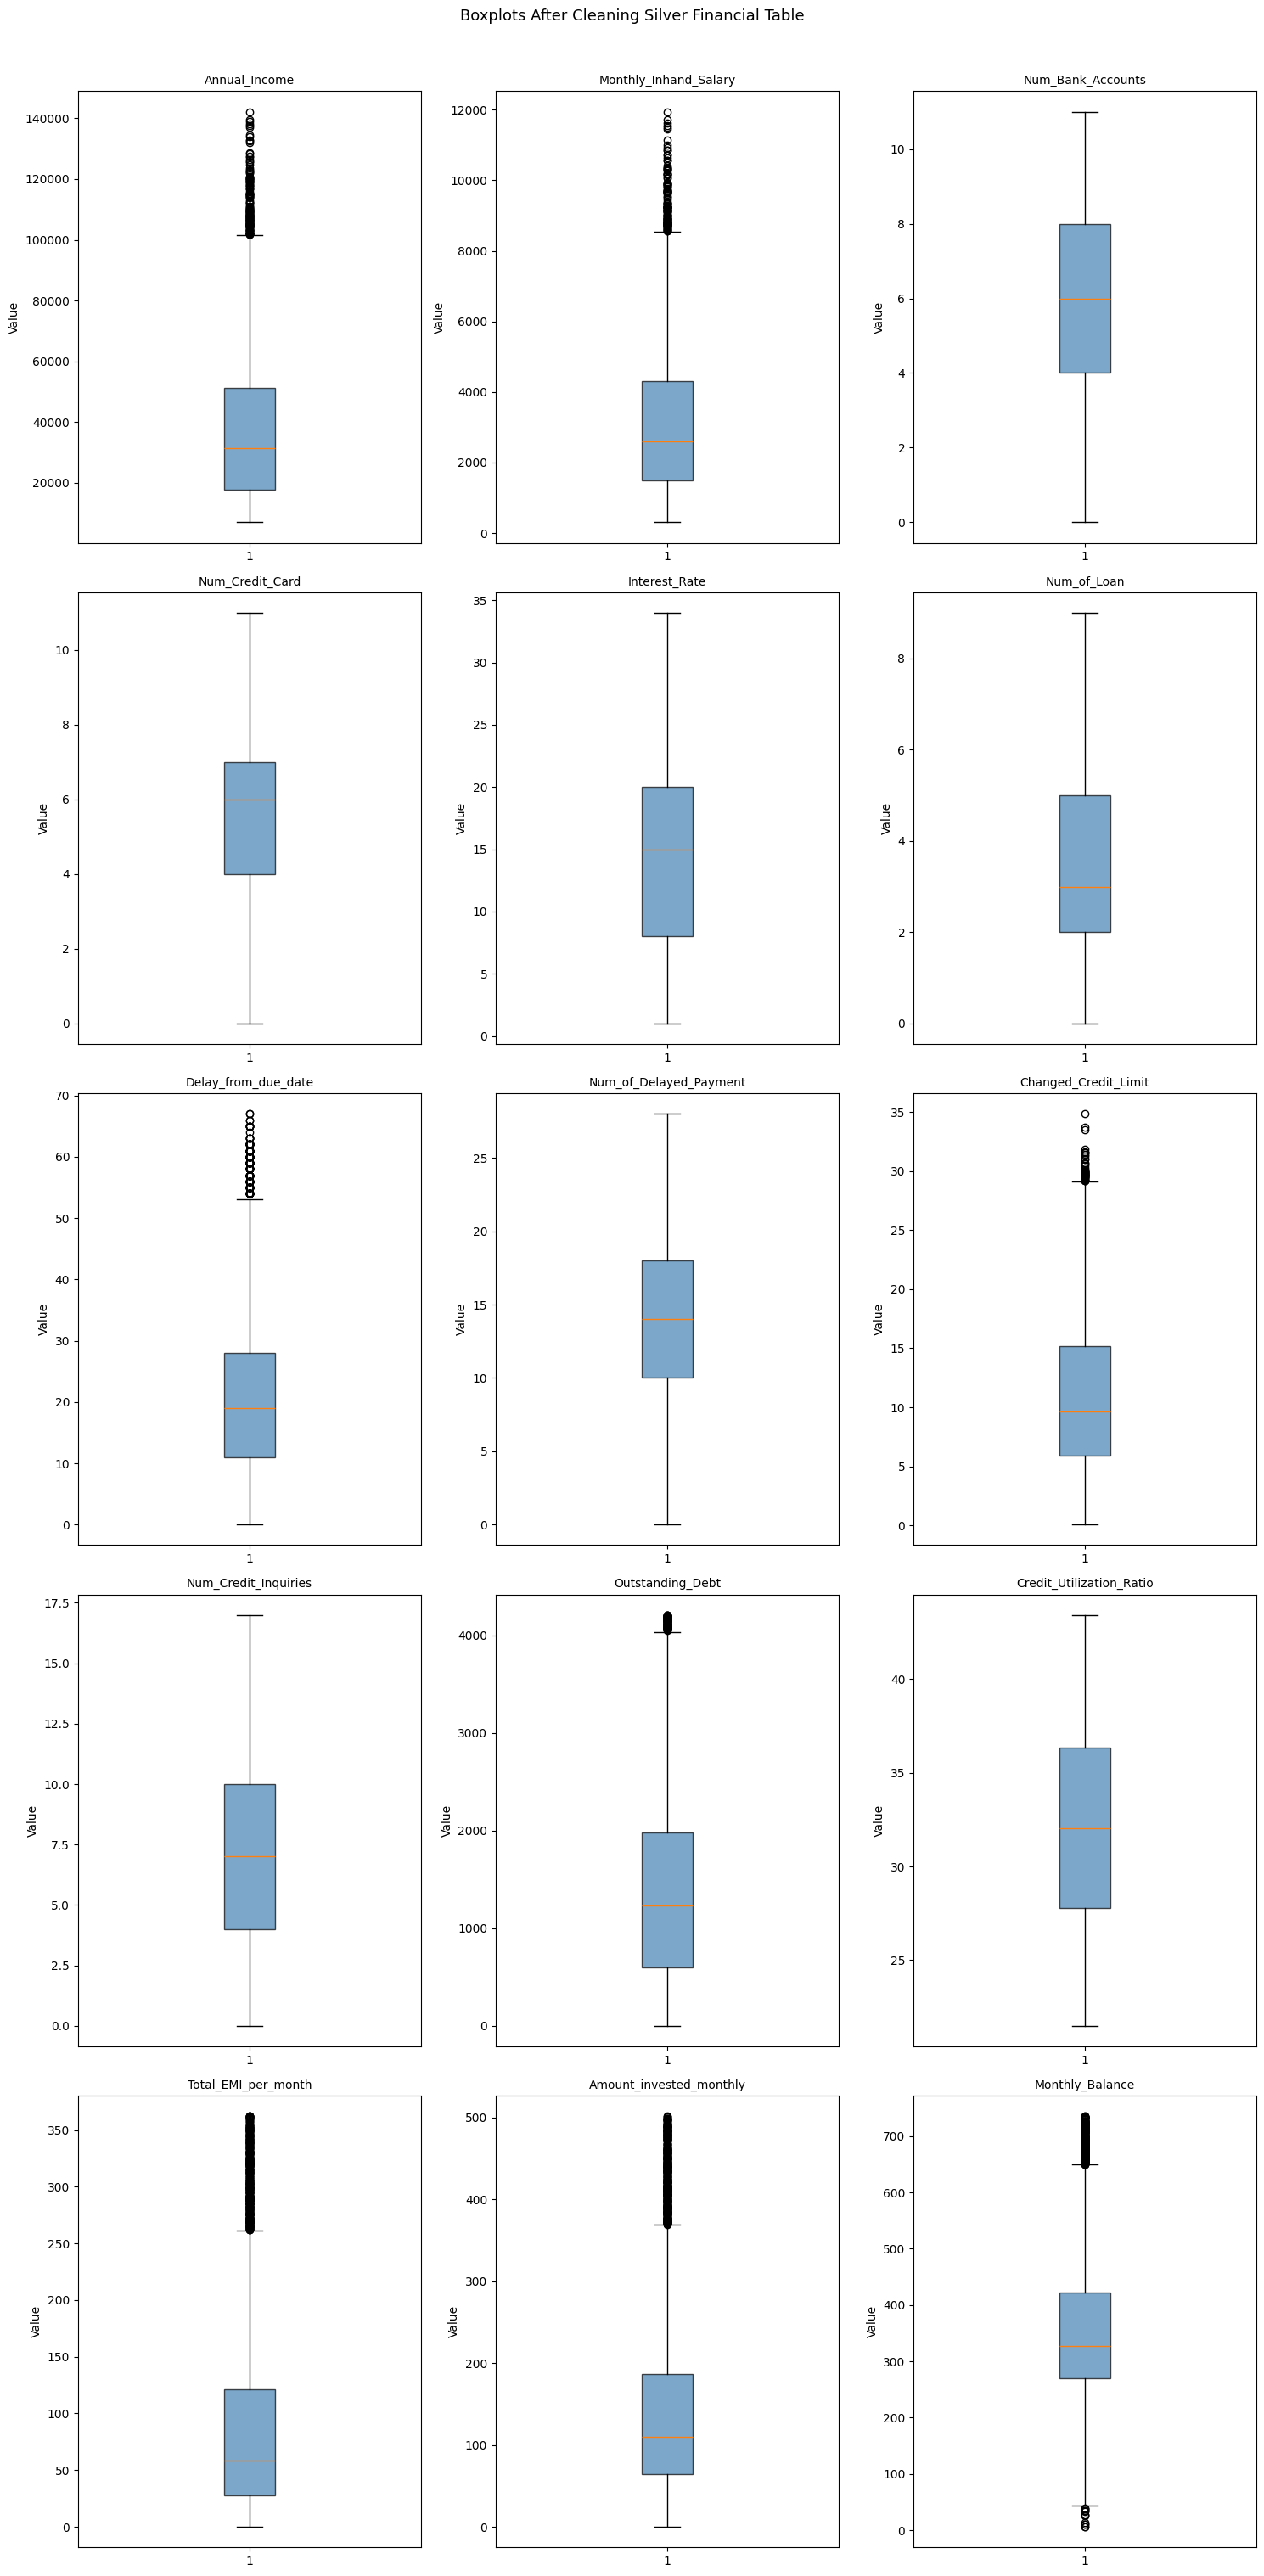

In [11]:
# Boxplot after cleaning to verify outlier and negative removal
filtered_pdf = filtered_df.toPandas()
num_cols_clean = filtered_pdf.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.flatten()

for i, col_name in enumerate(num_cols_clean):
    axes[i].boxplot(filtered_pdf[col_name].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.7))
    axes[i].set_title(col_name, fontsize=10)
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots After Cleaning Silver Financial Table", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Check for NULLs

In [12]:
# Check for NULLs and empty strings across all columns
null_counts = filtered_df.select([
    F.sum((F.col(c).isNull() | (F.col(c).cast("string") == "")).cast("int")).alias(c)
    for c in filtered_df.columns
]).toPandas().T.rename(columns={0: "null_count"})

null_counts["null_pct"] = (null_counts["null_count"] / filtered_df.count() * 100).round(2)
print(null_counts.to_string())

                          null_count  null_pct
Customer_ID                        0      0.00
Annual_Income                      0      0.00
Monthly_Inhand_Salary              0      0.00
Num_Bank_Accounts                  0      0.00
Num_Credit_Card                    0      0.00
Interest_Rate                      0      0.00
Num_of_Loan                        0      0.00
Type_of_Loan                     676      9.63
Delay_from_due_date                0      0.00
Num_of_Delayed_Payment             0      0.00
Changed_Credit_Limit               0      0.00
Num_Credit_Inquiries               0      0.00
Credit_Mix                      1468     20.92
Outstanding_Debt                   0      0.00
Credit_Utilization_Ratio           0      0.00
Credit_History_Age                 0      0.00
Payment_of_Min_Amount              0      0.00
Total_EMI_per_month                0      0.00
Amount_invested_monthly            0      0.00
Payment_Behaviour                  0      0.00
Monthly_Balan

## Missing Values Analysis and Garbage Strings

In [13]:
# Truncate the long DAG built up by the prior cleaning steps so Spark's
# whole-stage codegen does not exceed the 64KB Java method size limit.
filtered_df = filtered_df.localCheckpoint()

print(f"Rows before dropping: {filtered_df.count()}")

dropped_df = filtered_df.dropna()
print(f"Rows after dropping nulls: {dropped_df.count()}")

dropped_df = filtered_df.filter(col("Payment_of_Min_Amount") != "NM")
print(f"Rows after dropping NM in Payment_of_Min_Amount: {dropped_df.count()}")

dropped_df = filtered_df.filter(col("Payment_Behaviour") != "!@9#%8")
print(f"Rows after dropping !@9#%8 in Payment_Behaviour: {dropped_df.count()}")

Rows before dropping: 7017
Rows after dropping nulls: 5007
Rows after dropping NM in Payment_of_Min_Amount: 6226
Rows after dropping !@9#%8 in Payment_Behaviour: 6457


## Type_of_Loan Duplicate Check

In [14]:
import re
from collections import Counter
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType

def split_loan_types(loan_str):
    if loan_str is None:
        return None
    return [re.sub(r'^and\s+', '', p.strip()) for p in loan_str.split(",") if p.strip()]

def dedup_loan_types(loan_str):
    parts = split_loan_types(loan_str)
    if parts is None:
        return None
    seen = []
    for p in parts:
        if p and p not in seen:
            seen.append(p)
    return ", ".join(seen)

# Report which loan-type values appear more than once within the same row
split_udf = udf(split_loan_types, ArrayType(StringType()))
parts_pdf = (
    filtered_df
    .select(col("Type_of_Loan"))
    .withColumn("parts", split_udf(col("Type_of_Loan")))
    .filter(F.col("parts").isNotNull())
    .toPandas()
)

dup_counter = Counter()
rows_with_dups = 0
for parts in parts_pdf["parts"]:
    counts = Counter(parts)
    dups = {k: v for k, v in counts.items() if v > 1}
    if dups:
        rows_with_dups += 1
        for k, v in dups.items():
            dup_counter[k] += v - 1  # count only the extra occurrences

print(f"Rows with duplicate loan types in Type_of_Loan: {rows_with_dups}")
print("Loan types that appear duplicated (total extra occurrences):")
for loan_type, extra in dup_counter.most_common():
    print(f"  {loan_type}: {extra}")

# Apply deduplication
dedup_udf = udf(dedup_loan_types, StringType())
filtered_df = filtered_df.withColumn("Type_of_Loan", dedup_udf(col("Type_of_Loan")))

Rows with duplicate loan types in Type_of_Loan: 3115
Loan types that appear duplicated (total extra occurrences):
  Credit-Builder Loan: 645
  Payday Loan: 606
  Student Loan: 574
  Not Specified: 558
  Personal Loan: 558
  Debt Consolidation Loan: 558
  Mortgage Loan: 541
  Auto Loan: 533
  Home Equity Loan: 527
